In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import pymcel as pc

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


El problema comienza con 2 cuerpos que se atraen gravitacionalmente.

In [2]:
# Canonical Unitsss

G = 1

r1_vec_0 = np.array([0,0,0])
v1_vec_0 = np.array([0,0,0])
m1 = 1

r2_vec_0 = np.array([1,0,0])
v2_vec_0 = np.array([0,1,0])
m2 = 1

¿Cuál es la trayectoria que siguen estas 2 partículas? Existe la solución al problema relativo

In [ ]:
mu = G*(m1+m2)
r_vec_0 = r1_vec_0 - r2_vec_0
v_vec_0 = v1_vec_0 - v2_vec_0

r0 = np.linalg.norm(r_vec_0)
v0 = np.linalg.norm(v_vec_0)

In [ ]:
# Problem quadratures

# MARE
h_vec = np.cross(r_vec_0,v_vec_0)
h = np.linalg.norm(h_vec)           # Ctrl shift 7 fpr commenting all selected
h_vec, r_vec_0, v_vec_0

(array([0, 0, 1]), array([-1,  0,  0]), array([ 0, -1,  0]))

In [ ]:
# ERE
e_vec = np.cross(v_vec_0,h_vec)/mu - r_vec_0/r0
e = np.linalg.norm(e_vec)                          # min distance is at e_vec, e

e_vec, e

(array([0.5, 0. , 0. ]), np.float64(0.5))

In [ ]:
# Energy
epsilon = v0**2/2 - mu/r0

epsilon

np.float64(-1.5)

In [ ]:
e = np.sqrt(1 + 2*epsilon*h**2/mu**2)

e

np.float64(0.5)

In [ ]:
p = h**2/mu
q = p/(1+e)
Q = p/(1-e)

p, q, Q

(np.float64(0.5), np.float64(0.3333333333333333), np.float64(1.0))

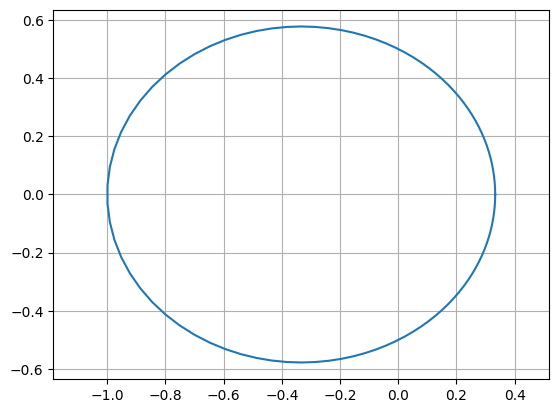

In [9]:
thetaer = np.linspace(0, 2 * np.pi, 100)
rs = p / (1 + e * np.cos(thetaer))

xfs = rs * np.cos(thetaer)
yfs = rs * np.sin(thetaer)

# Graph!! 
plt.plot(xfs, yfs)
plt.grid()
plt.axis('equal')
plt.show()

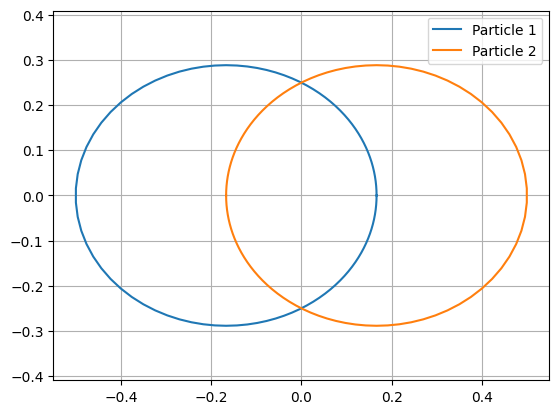

In [10]:
# Trayectory per particle

rvecs = np.array([xfs, yfs]).T

M = m1 + m2
r1vecs = m2 / M * rvecs
r2vecs = -m1 / M * rvecs


plt.plot(r1vecs[:,0], r1vecs[:,1], label='Particle 1')
plt.plot(r2vecs[:,0], r2vecs[:,1], label='Particle 2')
plt.grid()
plt.axis('equal')
plt.legend()
plt.show()

In [11]:
sistema = [
    dict(m=m1, r=r1_vec_0, v=v1_vec_0),
    dict(m=m2, r=r2_vec_0, v=v2_vec_0)
]

ts  = np.linspace(0, 3, 200)
rs, vs, rps, vps, cuadratura = pc.ncuerpos_solucion(sistema, ts)

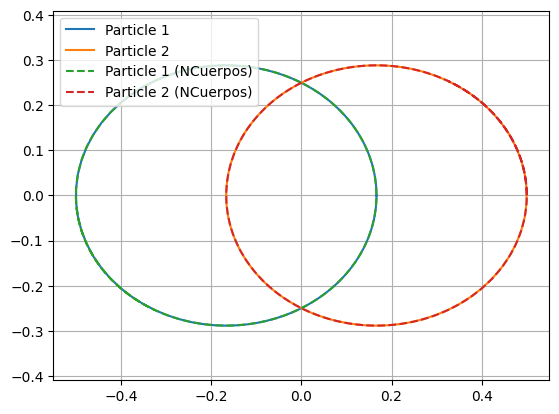

In [12]:
plt.plot(r1vecs[:,0], r1vecs[:,1], label='Particle 1')
plt.plot(r2vecs[:,0], r2vecs[:,1], label='Particle 2')

plt.plot(rps[0,:,0], rps[0,:,1], label='Particle 1 (NCuerpos)', linestyle='--')
plt.plot(rps[1,:,0], rps[1,:,1], label='Particle 2 (NCuerpos)', linestyle='--')
#plt.plot(r1_vec_0[0], r1_vec_0[1], 'ro', label='Initial Position 1')
#plt.plot(r2_vec_0[0], r2_vec_0[1], 'bo', label='Initial Position 2')
plt.grid()
plt.axis('equal')
plt.legend()
plt.show()

## Apophis!!

### Class April 16th

In [31]:
deg = np.pi/180

e = 0.1911663355386932 
a = 0.9223803173917017 
q = 0.7460522521429133 
i = 3.340958441017069* deg
node = 203.8996515621043*deg
peri = 126.6728325163065*deg

In [34]:
import spiceypy as spy

Rz_omega = spy.rotate(peri, 3)
Rx_i = spy.rotate(i, 1)
Rz_Omega = spy.rotate(node, 3)

M_astro2perifocal = Rz_omega @ Rx_i @ Rz_Omega
M_astro2perifocal

array([[ 0.87042569, -0.4900758 ,  0.04674214],
       [ 0.49173333,  0.87004992, -0.03480605],
       [-0.02361039,  0.05328075,  0.99830041]])

In [36]:
M_perifocal2astro = M_astro2perifocal.T
M_perifocal2astro

array([[ 0.87042569,  0.49173333, -0.02361039],
       [-0.4900758 ,  0.87004992,  0.05328075],
       [ 0.04674214, -0.03480605,  0.99830041]])

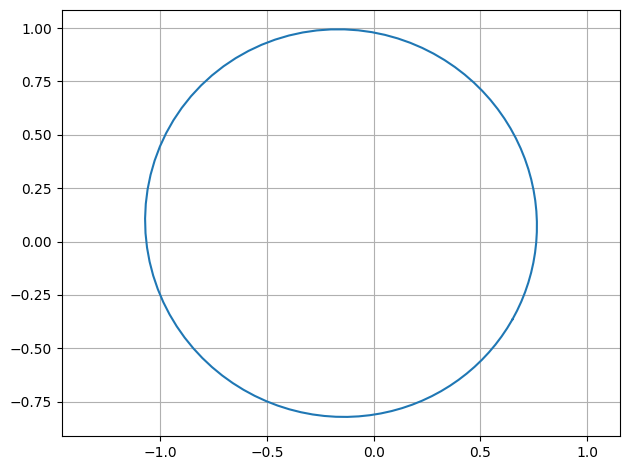

In [40]:
# Graph the Orbit

fs = np.linspace(0, 2*np.pi, 100)

p = q * (1 + e)
rs = p / (1 + e*np.cos(fs))

xfs = rs * np.cos(fs)
yfs = rs * np.sin(fs)
zfs = np.zeros_like(xfs)

# Este comando hace la multiplicación matricial
rvecs = (M_perifocal2astro @ np.array([xfs, yfs, zfs])).T

plt.plot(rvecs[:,0], rvecs[:,1])
plt.axis('equal')
plt.grid()
plt.tight_layout()

Text(0.5, 0, 'Z')

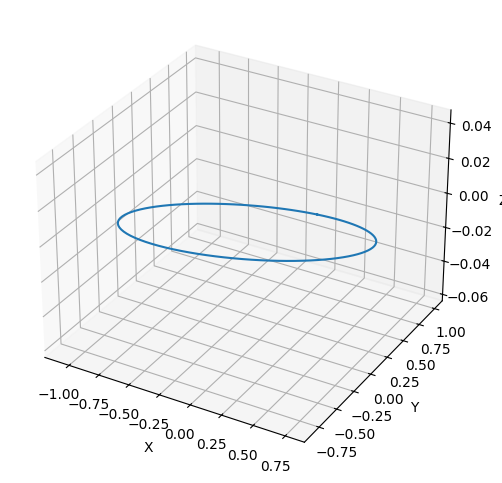

In [ ]:
# Graph the orbit in 3D
from mpl_toolkits.mplot3d import Axes3D

fs = np.linspace(0, 2*np.pi, 100)
plt.figure(figsize=(8, 6))
ax = plt.subplot(111, projection='3d')
rvecs = (M_perifocal2astro @ np.array([xfs, yfs, zfs])).T
ax.plot(rvecs[:,0], rvecs[:,1], rvecs[:,2])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')